# 🧠 출근 성실도 예측 모델 (RandomForest)

본 노트북은 출근기록 데이터를 기반으로 지각 여부를 예측합니다.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

plt.style.use('seaborn-v0_8')


In [2]:
df = pd.read_csv("employee_attendance_data.csv")
df.head()


,emp_id,gender,age,location,domicile_distance_km,transport_mode,day_of_week,is_holiday,entry_time,scheduled_time,lateness_min,lateness_label
0,E0164,M,23,PJOP_SURABAYA,8.1,Private_Vehicle,Monday,No,08:04,08:00,4,On_Time
1,E0174,M,49,ADMIN,1.9,Private_Vehicle,Tuesday,No,07:58,08:00,-1,On_Time
2,E0130,M,34,RND_CENTER,13.2,Bike,Friday,No,08:06,08:00,6,Late
3,E0072,M,32,HR_TEAM,10.9,Private_Vehicle,Tuesday,No,08:15,08:00,15,Late
4,E0196,F,28,ADMIN,12.0,Walking,Wednesday,No,07:57,08:00,-2,On_Time


lateness_label
On_Time    1440
Late        560
Name: count, dtype: int64


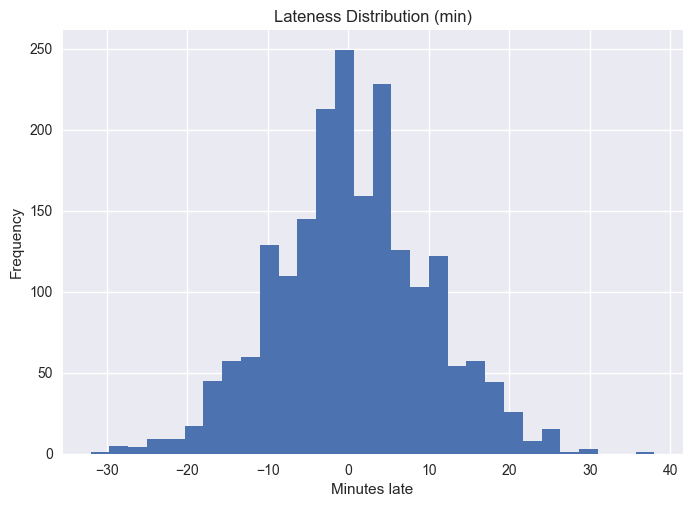

In [3]:
# 범주형 확인
print(df['lateness_label'].value_counts())
df['lateness_min'].hist(bins=30)
plt.title("Lateness Distribution (min)")
plt.xlabel("Minutes late")
plt.ylabel("Frequency")
plt.show()


In [4]:
df_clean = df.copy()

# Label Encoding
le = LabelEncoder()
df_clean['gender'] = le.fit_transform(df_clean['gender'])
df_clean['transport_mode'] = le.fit_transform(df_clean['transport_mode'])
df_clean['day_of_week'] = le.fit_transform(df_clean['day_of_week'])
df_clean['is_holiday'] = df_clean['is_holiday'].map({'Yes': 1, 'No': 0})
df_clean['location'] = le.fit_transform(df_clean['location'])
df_clean['lateness_label'] = df_clean['lateness_label'].map({'On_Time': 0, 'Late': 1})

# 시간 관련 제거
df_clean = df_clean.drop(columns=['entry_time', 'scheduled_time'])

df_clean.head()


c:\Users\olzld\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:605: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype):
c:\Users\olzld\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:614: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype) or not is_extension_array_dtype(pd_dtype):
c:\Users\olzld\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:605: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype):
c:\Users\olzld\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:614: FutureWarning: is_sparse is deprecated and will be removed in a

,emp_id,gender,age,location,domicile_distance_km,transport_mode,day_of_week,is_holiday,lateness_min,lateness_label
0,E0164,1,23,3,8.1,1,1,0,4,0
1,E0174,1,49,0,1.9,1,3,0,-1,0
2,E0130,1,34,4,13.2,0,0,0,6,1
3,E0072,1,32,1,10.9,1,3,0,15,1
4,E0196,0,28,0,12.0,3,4,0,-2,0


In [5]:
X = df_clean.drop(columns=['lateness_label', 'emp_id'])
y = df_clean['lateness_label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)


c:\Users\olzld\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:767: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if not hasattr(array, "sparse") and array.dtypes.apply(is_sparse).any():
c:\Users\olzld\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:605: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype):
c:\Users\olzld\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:614: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype) or not is_extension_array_dtype(pd_dtype):
c:\Users\olzld\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:605: FutureWarning:

RandomForestClassifier(random_state=42)

In [6]:
y_pred = model.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


[[283   0]
 [  0 117]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       283
           1       1.00      1.00      1.00       117

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400



c:\Users\olzld\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:767: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if not hasattr(array, "sparse") and array.dtypes.apply(is_sparse).any():
c:\Users\olzld\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:605: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype):
c:\Users\olzld\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:614: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype) or not is_extension_array_dtype(pd_dtype):
c:\Users\olzld\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:605: FutureWarning:

In [7]:
# 예시 입력
sample = X_test.iloc[0:1]
print("입력 샘플:")
print(sample)

predicted = model.predict(sample)
print("\n예측 결과 (0: On_Time, 1: Late):", predicted[0])


입력 샘플:
      gender  age  location  domicile_distance_km  transport_mode  \
1860       0   23         2                   7.0               3   

      day_of_week  is_holiday  lateness_min  
1860            4           0            -1  

예측 결과 (0: On_Time, 1: Late): 0


c:\Users\olzld\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:767: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if not hasattr(array, "sparse") and array.dtypes.apply(is_sparse).any():
c:\Users\olzld\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:605: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype):
c:\Users\olzld\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:614: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype) or not is_extension_array_dtype(pd_dtype):


In [ ]:
📊 성능 요약 (Noise Model)
구분	Precision	Recall	F1-score
On_Time (0)	0.69	0.88	0.78
Late (1)	0.19	0.07	0.10
전체 정확도	0.64